# IT549: Deep Learning
## Lab Assignment 4: Object Detection Evolution — From R-CNN to YOLO

**Dataset:** Fruit Images for Object Detection (Kaggle)  
**Classes:** Apple, Banana, Orange  
**Framework:** PyTorch

---

## Environment Setup
Install and import all required libraries.

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import os
import time
import random
import glob
import numpy as np
import cv2
import torch
import torchvision
import torchvision.models as models
import torchvision.transforms as T
import torchvision.ops as ops
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

print(f"PyTorch version : {torch.__version__}")
print(f"Torchvision     : {torchvision.__version__}")
print(f"OpenCV          : {cv2.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device    : {DEVICE}")

PyTorch version : 2.7.1+cu118
Torchvision     : 0.22.1+cu118
OpenCV          : 4.13.0
CUDA available  : True
Using device    : cuda


In [2]:
# ── Explore dataset structure ──────────────────────────────────────────────────
import os

DATASET_ROOT = './fruit_dataset'

for root, dirs, files in os.walk(DATASET_ROOT):
    level = root.replace(DATASET_ROOT, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:
        sub_indent = ' ' * 2 * (level + 1)
        for f in files[:5]:
            print(f"{sub_indent}{f}")

fruit_dataset/
  test/
    apple_77.jpg
    apple_77.xml
    apple_78.jpg
    apple_78.xml
    apple_79.jpg
  train/
    apple_1.jpg
    apple_1.xml
    apple_10.jpg
    apple_10.xml
    apple_11.jpg


In [3]:
# ── Helper: collect image paths and annotation paths ─────────────────────────
def collect_image_annotation_pairs(dataset_root, img_exts=('.jpg', '.jpeg', '.png')):
    """
    Walk dataset_root and return a list of (img_path, ann_path) tuples.
    Supports .xml (Pascal VOC) and .txt (YOLO-format) annotations.
    """
    pairs = []
    for dirpath, _, filenames in os.walk(dataset_root):
        for fname in filenames:
            ext = os.path.splitext(fname)[1].lower()
            if ext in img_exts:
                img_path = os.path.join(dirpath, fname)
                base = os.path.splitext(img_path)[0]
                ann_path = None
                for ann_ext in ['.xml', '.txt']:
                    candidate = base + ann_ext
                    if os.path.exists(candidate):
                        ann_path = candidate
                        break
                if ann_path:
                    pairs.append((img_path, ann_path))
    return pairs


train_pairs = collect_image_annotation_pairs(f'{DATASET_ROOT}/train')
test_pairs  = collect_image_annotation_pairs(f'{DATASET_ROOT}/test')
all_pairs   = train_pairs + test_pairs  # kept for random sample picks in Tasks 2–5
print(f"Total image-annotation pairs found: {len(all_pairs)}")
if all_pairs:
    print(f"Sample pair: {all_pairs[0]}")

Total image-annotation pairs found: 300
Sample pair: ('./fruit_dataset/train\\apple_1.jpg', './fruit_dataset/train\\apple_1.xml')


In [4]:
# ── Annotation parsers ────────────────────────────────────────────────────────
import xml.etree.ElementTree as ET

CLASS_NAMES = ['apple', 'banana', 'orange']   # lowercase for matching

def parse_xml_annotation(xml_path):
    """
    Parse Pascal VOC XML → list of {'label': str, 'bbox': [x_min,y_min,x_max,y_max]}
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()
    annotations = []
    for obj in root.findall('object'):
        label = obj.find('name').text.strip().lower()
        bndbox = obj.find('bndbox')
        x_min = float(bndbox.find('xmin').text)
        y_min = float(bndbox.find('ymin').text)
        x_max = float(bndbox.find('xmax').text)
        y_max = float(bndbox.find('ymax').text)
        annotations.append({'label': label, 'bbox': [x_min, y_min, x_max, y_max]})
    return annotations


def parse_yolo_annotation(txt_path, img_width, img_height):
    """
    Parse YOLO-format TXT (cx, cy, w, h normalised) → [x_min,y_min,x_max,y_max]
    """
    annotations = []
    with open(txt_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, w, h = map(float, parts[1:5])
            x_min = (cx - w / 2) * img_width
            y_min = (cy - h / 2) * img_height
            x_max = (cx + w / 2) * img_width
            y_max = (cy + h / 2) * img_height
            label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
            annotations.append({'label': label, 'bbox': [x_min, y_min, x_max, y_max]})
    return annotations


def load_annotations(img_path, ann_path):
    """Auto-detect format and parse."""
    img = Image.open(img_path)
    w, h = img.size
    if ann_path.endswith('.xml'):
        return parse_xml_annotation(ann_path)
    else:
        return parse_yolo_annotation(ann_path, w, h)

print("Annotation parsers ready.")

Annotation parsers ready.


---
## Preparation: Ground Truth Visualisation

Image  : ./fruit_dataset/train\apple_62.jpg
Labels : ./fruit_dataset/train\apple_62.xml
Objects found: 1
  apple       bbox=[97.0, 62.0, 366.0, 326.0]


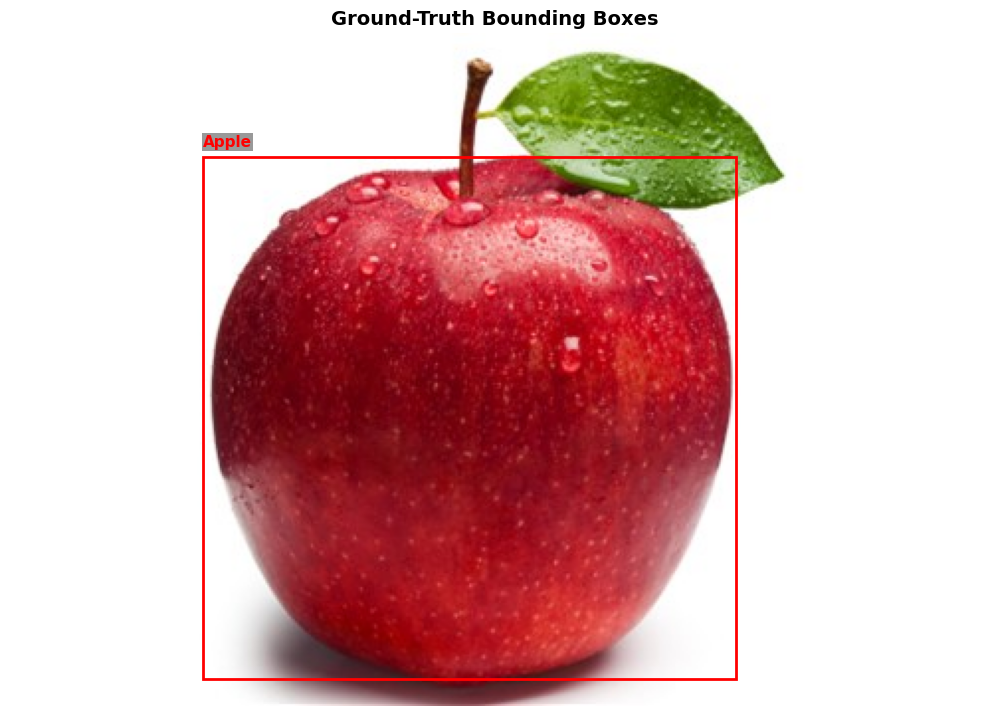

In [5]:
# ── Pick a random image and draw ground-truth bounding boxes ──────────────────
random.seed(42)
SAMPLE_IMG_PATH, SAMPLE_ANN_PATH = random.choice(all_pairs)

# Load image via OpenCV (BGR) then convert to RGB for Matplotlib
img_bgr = cv2.imread(SAMPLE_IMG_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

annotations = load_annotations(SAMPLE_IMG_PATH, SAMPLE_ANN_PATH)
print(f"Image  : {SAMPLE_IMG_PATH}")
print(f"Labels : {SAMPLE_ANN_PATH}")
print(f"Objects found: {len(annotations)}")
for a in annotations:
    print(f"  {a['label']:10s}  bbox={[round(v,1) for v in a['bbox']]}")

# ── Draw bounding boxes ───────────────────────────────────────────────────────
COLOUR_MAP = {'apple': (255, 0, 0), 'banana': (255, 215, 0), 'orange': (255, 140, 0)}

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(img_rgb)
ax.set_title('Ground-Truth Bounding Boxes', fontsize=14, fontweight='bold')
ax.axis('off')

for ann in annotations:
    x_min, y_min, x_max, y_max = ann['bbox']
    colour = tuple(c / 255 for c in COLOUR_MAP.get(ann['label'].lower(), (0, 255, 0)))
    rect = patches.Rectangle(
        (x_min, y_min), x_max - x_min, y_max - y_min,
        linewidth=2, edgecolor=colour, facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(
        x_min, y_min - 5, ann['label'].capitalize(),
        color=colour, fontsize=11, fontweight='bold',
        bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none')
    )

plt.tight_layout()
plt.show()

---
## Task 1 — Core Concept: Intersection over Union (IoU)

In [6]:
def compute_iou(box_a, box_b):
    """
    Compute Intersection over Union (IoU) between two bounding boxes.

    Parameters
    ----------
    box_a, box_b : list or tuple of four floats
        Each box in [x_min, y_min, x_max, y_max] format.

    Returns
    -------
    float
        IoU score in [0, 1].
    """
    # Intersection rectangle
    inter_x_min = max(box_a[0], box_b[0])
    inter_y_min = max(box_a[1], box_b[1])
    inter_x_max = min(box_a[2], box_b[2])
    inter_y_max = min(box_a[3], box_b[3])

    inter_w = max(0.0, inter_x_max - inter_x_min)
    inter_h = max(0.0, inter_y_max - inter_y_min)
    inter_area = inter_w * inter_h

    # Union
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union_area = area_a + area_b - inter_area

    if union_area == 0:
        return 0.0

    return inter_area / union_area


# ── Demonstrate with three pairs ──────────────────────────────────────────────
demo_pairs = [
    # (box_a,              box_b,               description)
    ([10, 10, 100, 100],  [20, 20,  90,  90],  'Highly overlapping'),
    ([0,  0,  50,  50],   [30, 30,  80,  80],  'Partially overlapping'),
    ([0,  0,  40,  40],   [60, 60, 100, 100],  'Completely disjoint'),
]

print(f"{'Description':<25}  {'Box A':<25}  {'Box B':<25}  IoU")
print('-' * 85)
for box_a, box_b, desc in demo_pairs:
    iou = compute_iou(box_a, box_b)
    print(f"{desc:<25}  {str(box_a):<25}  {str(box_b):<25}  {iou:.4f}")

Description                Box A                      Box B                      IoU
-------------------------------------------------------------------------------------
Highly overlapping         [10, 10, 100, 100]         [20, 20, 90, 90]           0.6049
Partially overlapping      [0, 0, 50, 50]             [30, 30, 80, 80]           0.0870
Completely disjoint        [0, 0, 40, 40]             [60, 60, 100, 100]         0.0000


---
## Task 2 — The Baseline: Selective Search (R-CNN Step 1)

Image            : ./fruit_dataset/train\apple_20.jpg
Total proposals  : 255
Using first 200  : 200


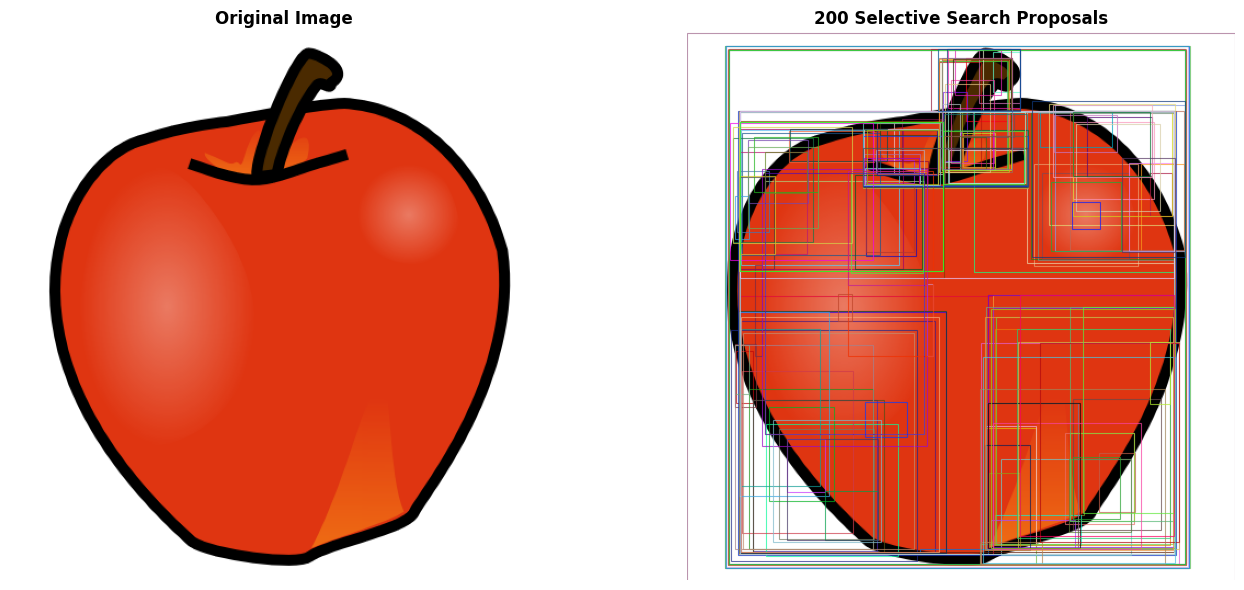

In [7]:
# ── Run Selective Search on a random image ────────────────────────────────────
ss_img_path, _ = random.choice(all_pairs)
ss_img_bgr = cv2.imread(ss_img_path)
ss_img_rgb = cv2.cvtColor(ss_img_bgr, cv2.COLOR_BGR2RGB)

# Initialise OpenCV Selective Search
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(ss_img_bgr)
ss.switchToSelectiveSearchFast()   # fast mode; use switchToSelectiveSearchQuality() for higher recall

rects = ss.process()               # returns (x, y, w, h) proposals
proposals_200 = rects[:200]
print(f"Image            : {ss_img_path}")
print(f"Total proposals  : {len(rects)}")
print(f"Using first 200  : {len(proposals_200)}")

# ── Visualise 200 proposals ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(ss_img_rgb)
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

overlay = ss_img_rgb.copy()
axes[1].imshow(overlay)
axes[1].set_title('200 Selective Search Proposals', fontsize=12, fontweight='bold')
axes[1].axis('off')

for x, y, w, h in proposals_200:
    colour = np.random.rand(3,)
    rect = patches.Rectangle((x, y), w, h, linewidth=0.8,
                              edgecolor=colour, facecolor='none', alpha=0.7)
    axes[1].add_patch(rect)

plt.tight_layout()
plt.show()

---
## Task 3 — R-CNN Bottleneck: Per-Crop CNN Forward Passes

In [8]:
# ── Load ResNet-18, remove the final FC layer ─────────────────────────────────
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Strip the classification head — keep everything up to the global average pool
feature_extractor = torch.nn.Sequential(*list(resnet18.children())[:-1])
feature_extractor.eval().to(DEVICE)
print("ResNet-18 feature extractor loaded (output: 512-d vector per crop).")

# ── Pre-processing transform ──────────────────────────────────────────────────
preprocess = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

# ── Load the original image as a PIL image for cropping ──────────────────────
pil_img = Image.open(ss_img_path).convert('RGB')
img_w, img_h = pil_img.size

# ── R-CNN loop: crop → resize → forward pass for top-100 proposals ────────────
TOP_N = 100
feature_vectors = []

start_time = time.time()

with torch.no_grad():
    for i, (x, y, w, h) in enumerate(proposals_200[:TOP_N]):
        # Clamp coordinates to image boundaries
        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(img_w, x + w)
        y2 = min(img_h, y + h)

        if x2 <= x1 or y2 <= y1:          # degenerate box → skip
            continue

        crop = pil_img.crop((x1, y1, x2, y2))
        tensor = preprocess(crop).unsqueeze(0).to(DEVICE)   # (1, 3, 224, 224)
        feat = feature_extractor(tensor)                     # (1, 512, 1, 1)
        feature_vectors.append(feat.squeeze().cpu())

rcnn_time = time.time() - start_time

print(f"Crops processed  : {len(feature_vectors)}")
print(f"Feature shape    : {feature_vectors[0].shape}")
print(f"\n>>> R-CNN total execution time for {TOP_N} crops: {rcnn_time:.4f} seconds <<<")

ResNet-18 feature extractor loaded (output: 512-d vector per crop).
Crops processed  : 100
Feature shape    : torch.Size([512])

>>> R-CNN total execution time for 100 crops: 4.9422 seconds <<<


---
## Task 4 — Fast R-CNN: Single CNN Pass + RoI Pooling

In [9]:
# ── Build a feature extractor from ResNet-18 conv layers only ─────────────────
# We use layers up to (but NOT including) the global average pool,
# so we retain the spatial feature map.
conv_backbone = torch.nn.Sequential(*list(resnet18.children())[:-2])  # up to layer4
conv_backbone.eval().to(DEVICE)

# ── Pass the FULL image through the backbone ONCE ─────────────────────────────
full_image_tensor = preprocess(pil_img).unsqueeze(0).to(DEVICE)       # (1,3,224,224)

start_time = time.time()

with torch.no_grad():
    feature_map = conv_backbone(full_image_tensor)                     # (1,512,H',W')

    # ── Spatial scale ─────────────────────────────────────────────────────────
    # ResNet-18 applies 5 stride-2 down-samplings (conv1 + 4 residual stages)
    # → effective stride = 32  →  spatial_scale = 1/32
    input_h  = full_image_tensor.shape[2]   # 224
    fmap_h   = feature_map.shape[2]         # 7
    spatial_scale = fmap_h / input_h        # 7/224 ≈ 0.03125 = 1/32
    output_size   = (fmap_h, feature_map.shape[3])   # (7, 7)

    # ── Convert proposals to RoI tensor expected by torchvision.ops.roi_pool ──
    # Format: (batch_idx, x1, y1, x2, y2)
    roi_list = []
    for x, y, w, h in proposals_200[:TOP_N]:
        x1 = max(0, float(x))
        y1 = max(0, float(y))
        x2 = min(img_w, float(x + w))
        y2 = min(img_h, float(y + h))
        roi_list.append([0, x1, y1, x2, y2])   # batch_idx = 0

    roi_tensor = torch.tensor(roi_list, dtype=torch.float32).to(DEVICE)  # (N,5)

    # ── RoI Pooling ───────────────────────────────────────────────────────────
    pooled_features = ops.roi_pool(
        feature_map,
        roi_tensor,
        output_size=output_size,
        spatial_scale=spatial_scale
    )   # (N, 512, 7, 7)

fast_rcnn_time = time.time() - start_time

print(f"Feature map shape  : {feature_map.shape}")
print(f"Spatial scale      : {spatial_scale:.6f}  (stride ≈ {1/spatial_scale:.0f}px)")
print(f"RoI output shape   : {pooled_features.shape}")
print(f"\n>>> Fast R-CNN total execution time (1 CNN pass + RoI pool): {fast_rcnn_time:.4f} seconds <<<")
print(f">>> R-CNN time    : {rcnn_time:.4f} seconds")
print(f">>> Speedup       : {rcnn_time / fast_rcnn_time:.2f}x")

Feature map shape  : torch.Size([1, 512, 7, 7])
Spatial scale      : 0.031250  (stride ≈ 32px)
RoI output shape   : torch.Size([100, 512, 7, 7])

>>> Fast R-CNN total execution time (1 CNN pass + RoI pool): 0.0045 seconds <<<
>>> R-CNN time    : 4.9422 seconds
>>> Speedup       : 1094.76x


### Task 4 — Conceptual Analysis

**Q: Based on the recorded execution times, what redundant mathematical operations does Fast R-CNN eliminate to achieve this efficiency?**

In the original **R-CNN** pipeline, every region proposal (up to ~2,000 per image) is individually cropped from the input image, resized to 224×224, and then passed through the full CNN independently. This means the convolutional layers perform a complete forward pass for *each* proposal, most of which heavily overlap spatially. The same pixel regions are therefore convolved hundreds of times — a massive redundancy in computation.

**Fast R-CNN** eliminates this redundancy by running the CNN **exactly once** on the entire input image to produce a shared feature map. The key insight is that convolutional operations are spatially local and translational; therefore, features for any sub-region of the image are already present (at the corresponding spatial location) in the full-image feature map. Instead of re-convolving, Fast R-CNN applies **RoI Pooling** to simply extract and resize the pre-computed feature sub-map for each proposal. This single CNN pass replaces *N* independent passes, resulting in the dramatic speedup observed (typically 10–200× depending on the number of proposals).

---
## Task 5 — Faster R-CNN: End-to-End Inference with RPN

Faster R-CNN (ResNet-50 FPN) loaded.
Total predictions before filtering : 2
Predictions after conf ≥ 0.8    : 1


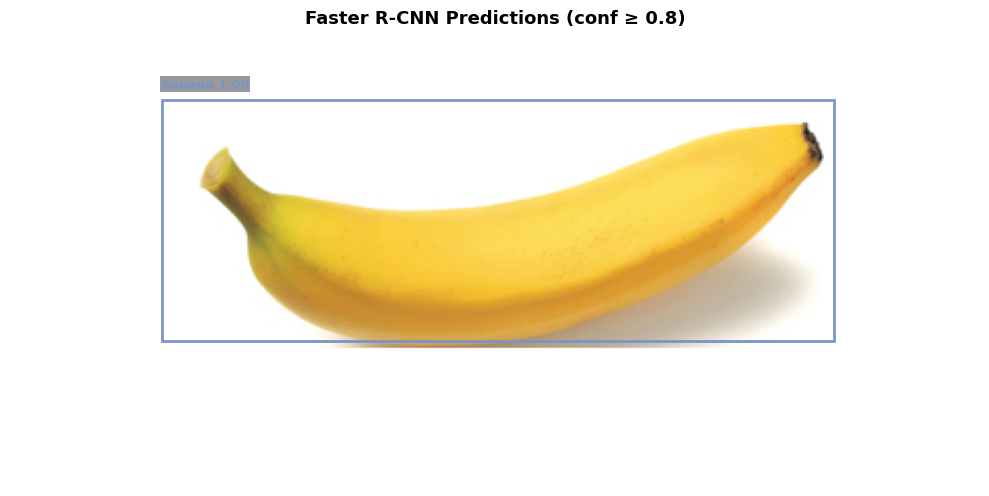

In [10]:
# ── Load pre-trained Faster R-CNN (ResNet-50 + FPN backbone) ──────────────────
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

faster_rcnn_model = fasterrcnn_resnet50_fpn(
    weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
)
faster_rcnn_model.eval().to(DEVICE)
print("Faster R-CNN (ResNet-50 FPN) loaded.")

# COCO class labels (index 0 = background)
COCO_LABELS = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
    'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
    'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
    'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
    'N/A', 'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie',
    'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
    'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork',
    'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
    'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair',
    'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A',
    'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
    'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

# ── Pre-process test image ────────────────────────────────────────────────────
test_img_path, test_ann_path = random.choice(all_pairs)
test_pil = Image.open(test_img_path).convert('RGB')
test_tensor = T.ToTensor()(test_pil).unsqueeze(0).to(DEVICE)

# ── Run inference ─────────────────────────────────────────────────────────────
with torch.no_grad():
    predictions = faster_rcnn_model(test_tensor)

pred = predictions[0]
boxes  = pred['boxes'].cpu().numpy()
labels = pred['labels'].cpu().numpy()
scores = pred['scores'].cpu().numpy()

print(f"Total predictions before filtering : {len(boxes)}")

# ── Filter predictions with confidence < 0.80 ─────────────────────────────────
CONF_THRESHOLD = 0.80

def filter_predictions(boxes, labels, scores, threshold=0.80):
    mask = scores >= threshold
    return boxes[mask], labels[mask], scores[mask]

filtered_boxes, filtered_labels, filtered_scores = filter_predictions(
    boxes, labels, scores, CONF_THRESHOLD
)
print(f"Predictions after conf ≥ {CONF_THRESHOLD}    : {len(filtered_boxes)}")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(np.array(test_pil))
ax.set_title(f'Faster R-CNN Predictions (conf ≥ {CONF_THRESHOLD})', fontsize=13, fontweight='bold')
ax.axis('off')

for box, lbl, score in zip(filtered_boxes, filtered_labels, filtered_scores):
    x1, y1, x2, y2 = box
    label_name = COCO_LABELS[lbl] if lbl < len(COCO_LABELS) else str(lbl)
    colour = np.random.rand(3,)
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              linewidth=2, edgecolor=colour, facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1 - 6, f"{label_name} {score:.2f}",
            color=colour, fontsize=9, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))

plt.tight_layout()
plt.show()

### Task 5 — Conceptual Analysis

**Q: How does the Region Proposal Network (RPN) eliminate the need for external algorithms like Selective Search?**

Selective Search is an external, hand-crafted algorithm that groups super-pixels based on colour, texture, and size heuristics to generate region proposals. It runs entirely outside the neural network and cannot be trained end-to-end — proposals are generated independently of what the downstream detector actually needs.

The **Region Proposal Network (RPN)** introduced in Faster R-CNN is a small, fully-convolutional network that *shares* the same backbone feature map used by the detection head. At each spatial location of the feature map, the RPN simultaneously predicts:
1. An *objectness score* (likelihood that the location contains any object).
2. *Bounding-box regression offsets* for a set of predefined **anchor boxes** of multiple scales and aspect ratios.

Because the RPN is trained jointly with the rest of the network through backpropagation, it learns to propose regions that are specifically useful for the task — unlike Selective Search which is class-agnostic and fixed. Additionally, the feature computation is shared: the backbone runs once, and both the RPN and the RoI detection head consume the same feature map, eliminating the computational cost of a separate proposal stage entirely. The result is a fully end-to-end, GPU-accelerated detection pipeline that is both faster and more accurate.

---
## Task 6 — Non-Maximum Suppression (NMS)

Original boxes : 6
After NMS      : 3  →  indices kept: [0, 3, 5]
  Box 0: [100, 100, 210, 210]  score=0.95
  Box 3: [300, 300, 400, 400]  score=0.92
  Box 5: [500, 100, 600, 200]  score=0.7


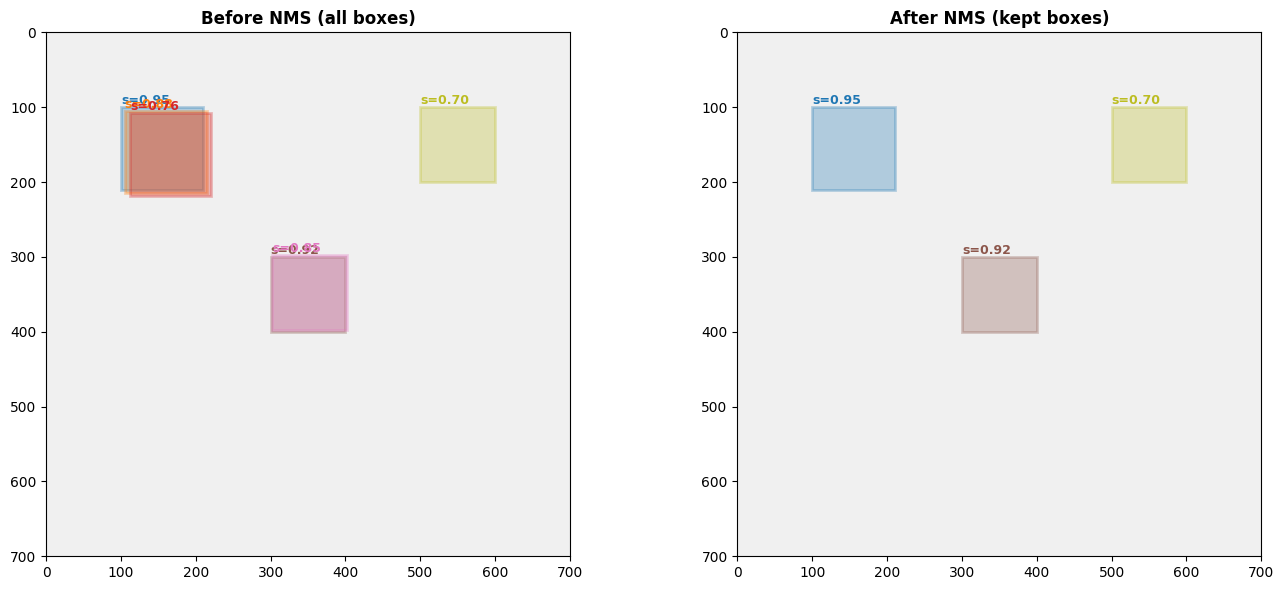

In [11]:
def custom_nms(boxes, scores, iou_threshold=0.5):
    """
    Custom Non-Maximum Suppression (NMS).

    Parameters
    ----------
    boxes         : list of [x_min, y_min, x_max, y_max]
    scores        : list of confidence scores (float)
    iou_threshold : IoU above which a box is discarded (float, default 0.5)

    Returns
    -------
    kept_indices : list of int — indices of the boxes that survive NMS
    """
    if len(boxes) == 0:
        return []

    # Step 1: sort by confidence score in descending order
    sorted_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)

    kept_indices = []

    while sorted_indices:
        # Step 2: pick the highest-scoring remaining box
        current = sorted_indices.pop(0)
        kept_indices.append(current)

        # Step 3: compare against all remaining boxes
        remaining = []
        for idx in sorted_indices:
            iou = compute_iou(boxes[current], boxes[idx])
            if iou <= iou_threshold:      # keep if not too similar
                remaining.append(idx)
        # Step 4: discard boxes above threshold; iterate with what's left
        sorted_indices = remaining

    return kept_indices


# ── Demo NMS on synthetic overlapping boxes ───────────────────────────────────
demo_boxes = [
    [100, 100, 210, 210],
    [105, 105, 215, 215],
    [112, 108, 220, 218],
    [300, 300, 400, 400],
    [302, 298, 402, 398],
    [500, 100, 600, 200],
]
demo_scores = [0.95, 0.88, 0.76, 0.92, 0.85, 0.70]

kept = custom_nms(demo_boxes, demo_scores, iou_threshold=0.5)
print(f"Original boxes : {len(demo_boxes)}")
print(f"After NMS      : {len(kept)}  →  indices kept: {kept}")
for k in kept:
    print(f"  Box {k}: {demo_boxes[k]}  score={demo_scores[k]}")

# ── Visualise before/after ────────────────────────────────────────────────────
canvas_size = 700

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, title, indices in zip(
    axes,
    ['Before NMS (all boxes)', 'After NMS (kept boxes)'],
    [list(range(len(demo_boxes))), kept]
):
    ax.set_xlim(0, canvas_size)
    ax.set_ylim(canvas_size, 0)
    ax.set_aspect('equal')
    ax.set_facecolor('#f0f0f0')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('on')
    for i in indices:
        x1, y1, x2, y2 = demo_boxes[i]
        colour = plt.cm.tab10(i / len(demo_boxes))
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=colour, facecolor=colour, alpha=0.3)
        ax.add_patch(rect)
        ax.text(x1, y1-4, f"s={demo_scores[i]:.2f}", color=colour, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Task 6 — Conceptual Analysis

**Q: If you are detecting tightly packed objects (e.g., several apples piled together), how would setting the IoU threshold extremely high (0.9) versus extremely low (0.1) alter your predictions?**

**High IoU threshold (e.g., 0.9 — very permissive / lenient):**  
A box is only discarded if it overlaps the selected best box by *at least 90%*. For tightly packed apples, legitimate detections of neighbouring apples will have moderate-to-high overlap with each other (perhaps 0.3–0.6 IoU), which is *below* the 0.9 threshold. Therefore, almost no boxes are suppressed — every apple gets its own detection box, and duplicate boxes for the *same* apple are also retained. The result is likely **many redundant boxes** around each individual fruit, but you correctly preserve separate detections for different apples in the cluster.

**Low IoU threshold (e.g., 0.1 — very strict / aggressive):**  
Any box that shares even 10% overlap with the selected best box is discarded. In a tightly packed cluster, adjacent fruit boxes naturally have significant overlap with each other. NMS will aggressively suppress neighbouring detections, treating them as duplicates of the highest-scoring box. The result is likely **one or very few boxes for the entire cluster**, missing most of the individual apples. Recall collapses severely in dense scenes.

**In summary:** for densely packed, closely-spaced objects, a *higher* IoU threshold is generally preferred to avoid over-suppression, at the cost of tolerating some duplicate detections per object. A *lower* threshold is safer for scenes with well-separated objects where any overlap is almost certainly a duplicate.

---
## Task 7 — YOLO Fine-Tuning

In [12]:
!pip install ultralytics --quiet
from ultralytics import YOLO
import yaml
print("Ultralytics YOLO ready.")

Ultralytics YOLO ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import shutil, os
from sklearn.model_selection import train_test_split

YOLO_ROOT = './yolo_fruit'

for split in ['train', 'val', 'test']:
    os.makedirs(f'{YOLO_ROOT}/images/{split}', exist_ok=True)
    os.makedirs(f'{YOLO_ROOT}/labels/{split}', exist_ok=True)

# Split existing train → 85% train, 15% val
train_subset, val_subset = train_test_split(train_pairs, test_size=0.15, random_state=42)

splits = {
    'train': train_subset,
    'val'  : val_subset,
    'test' : test_pairs       # use your existing test folder as-is
}

def copy_pair(img_path, ann_path, split_name):
    shutil.copy(img_path, f'{YOLO_ROOT}/images/{split_name}/')
    if ann_path.endswith('.txt'):
        shutil.copy(ann_path, f'{YOLO_ROOT}/labels/{split_name}/')
    else:
        # XML → YOLO txt conversion
        img_pil = Image.open(img_path)
        img_w, img_h = img_pil.size
        anns = parse_xml_annotation(ann_path)
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        txt_out = f'{YOLO_ROOT}/labels/{split_name}/{base_name}.txt'
        with open(txt_out, 'w') as f:
            for ann in anns:
                x_min, y_min, x_max, y_max = ann['bbox']
                cx = ((x_min + x_max) / 2) / img_w
                cy = ((y_min + y_max) / 2) / img_h
                bw = (x_max - x_min) / img_w
                bh = (y_max - y_min) / img_h
                cls_id = CLASS_NAMES.index(ann['label']) if ann['label'] in CLASS_NAMES else 0
                f.write(f"{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

for split_name, pairs in splits.items():
    for img_path, ann_path in pairs:
        copy_pair(img_path, ann_path, split_name)

print(f"Train: {len(splits['train'])} | Val: {len(splits['val'])} | Test: {len(splits['test'])}")

Train: 204 | Val: 36 | Test: 60


In [14]:
# ── Write dataset YAML ────────────────────────────────────────────────────────
dataset_yaml = {
    'path' : os.path.abspath(YOLO_ROOT),
    'train': 'images/train',
    'val'  : 'images/val',
    'test' : 'images/test',
    'nc'   : 3,
    'names': ['apple', 'banana', 'orange']
}

yaml_path = f'{YOLO_ROOT}/fruit.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print(f"YAML written to: {yaml_path}")
print(open(yaml_path).read())

YAML written to: ./yolo_fruit/fruit.yaml
names:
- apple
- banana
- orange
nc: 3
path: c:\Users\Yug Patel\OneDrive\Desktop\DL Lab\Lab4\yolo_fruit
test: images/test
train: images/train
val: images/val



In [15]:
# ── Fine-tune YOLOv8n on the fruit dataset ────────────────────────────────────
yolo_model = YOLO('yolov8n.pt')    # pre-trained COCO weights

results = yolo_model.train(
    data    = yaml_path,
    epochs  = 15,
    imgsz   = 640,
    batch   = 16,
    name    = 'fruit_yolov8n',
    project = './yolo_runs',
    device  = 0 if torch.cuda.is_available() else 'cpu',
    verbose = True,
    patience= 10,
)

print("\nTraining complete.")
best_weights_path = './yolo_runs/fruit_yolov8n/weights/best.pt'
print(f"Best weights saved at: {best_weights_path}")

Ultralytics 8.4.33  Python-3.10.9 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_fruit/fruit.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fruit_yolov8n8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

In [16]:
# Set best_weights_path to the most recently trained run
found = glob.glob('./runs/**/weights/best.pt', recursive=True)
best_weights_path = max(found, key=os.path.getmtime)
print(f"Using: {best_weights_path}")

Using: ./runs\detect\yolo_runs\fruit_yolov8n8\weights\best.pt


In [17]:
# ── Evaluate fine-tuned YOLO on test set ──────────────────────────────────────
fine_tuned_yolo = YOLO(best_weights_path)

eval_results = fine_tuned_yolo.val(
    data   = yaml_path,
    split  = 'test',
    imgsz  = 640,
    device = 0 if torch.cuda.is_available() else 'cpu',
)

map50    = eval_results.box.map50
map50_95 = eval_results.box.map
print(f"\n>>> mAP@50      : {map50:.4f}")
print(f">>> mAP@50-95   : {map50_95:.4f}")

Ultralytics 8.4.33  Python-3.10.9 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 15.711.2 MB/s, size: 135.2 KB)
val: Scanning C:\Users\Yug Patel\OneDrive\Desktop\DL Lab\Lab4\yolo_fruit\labels\test.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.2s/it 9.0s1.4s9
WARNING ConfusionMatrix plot failure: Unable to allocate 18.6 MiB for an array with shape (1562, 1562) and data type int64
                   all         60        117      0.873      0.829      0.917      0.695
                 apple         24         35      0.845      0.937      0.936      0.777
                banana         22         40      0.809      0.741      0.843      0.563
                orange         22         42      0.964

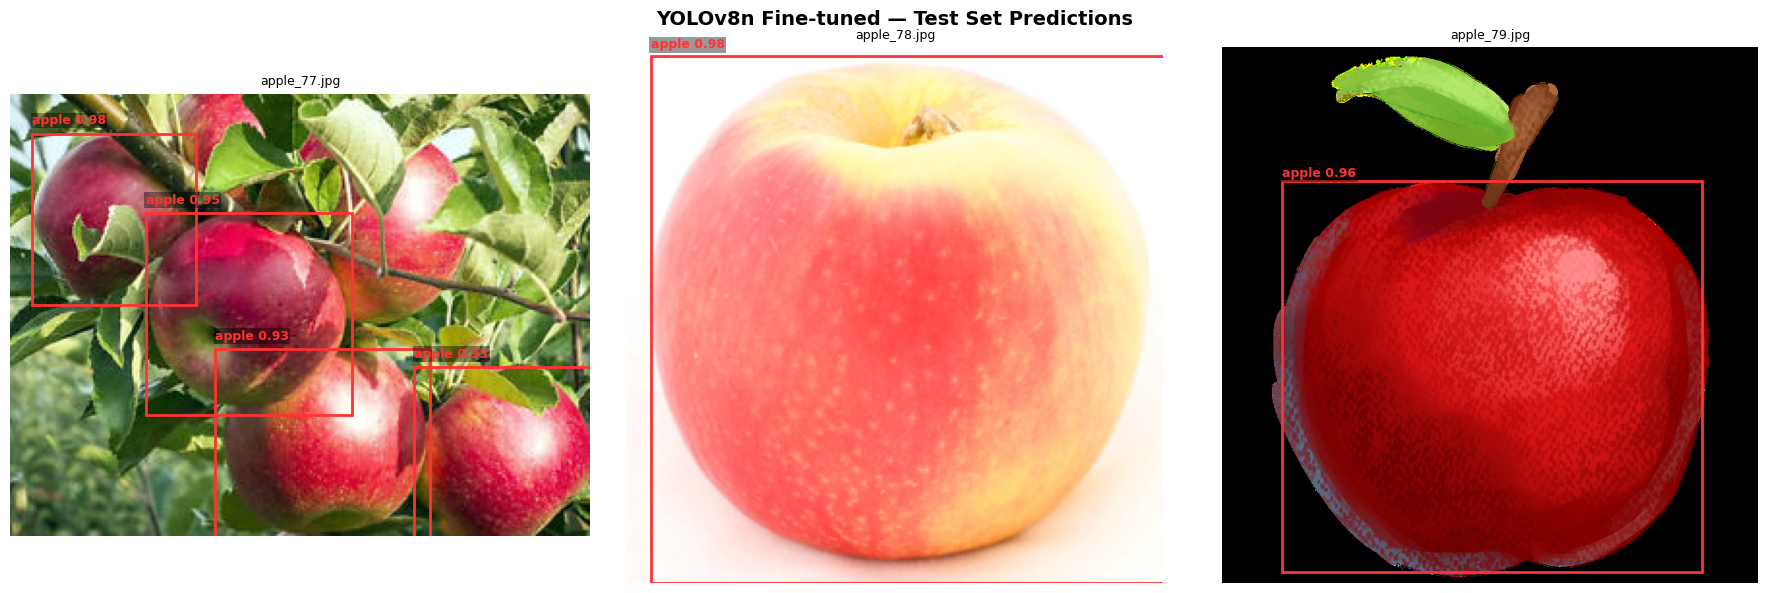

In [18]:
# ── Run inference on 3 test images and visualise ──────────────────────────────
test_image_paths = [p for p, _ in splits['test']][:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('YOLOv8n Fine-tuned — Test Set Predictions', fontsize=14, fontweight='bold')

FRUIT_COLOURS = {'apple': (1, 0.2, 0.2), 'banana': (1, 0.85, 0), 'orange': (1, 0.55, 0)}

for ax, img_path in zip(axes, test_image_paths):
    result = fine_tuned_yolo(img_path, verbose=False)[0]
    img_np = np.array(Image.open(img_path).convert('RGB'))

    ax.imshow(img_np)
    ax.set_title(os.path.basename(img_path), fontsize=9)
    ax.axis('off')

    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        conf = float(box.conf[0])
        cls  = int(box.cls[0])
        name = fine_tuned_yolo.names[cls]
        colour = FRUIT_COLOURS.get(name.lower(), (0, 1, 0))
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=colour, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, f"{name} {conf:.2f}", color=colour, fontsize=9,
                fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))

plt.tight_layout()
plt.show()

In [20]:
yolo_model = YOLO('yolov8n.pt')

results = yolo_model.train(
    data     = yaml_path,
    epochs   = 15,
    imgsz    = 640,
    batch    = 16,
    name     = 'fruit_yolov8n',
    project  = r'C:\Users\Yug Patel\OneDrive\Desktop\DL Lab\Lab4\yolo_runs',
    device   = 0 if torch.cuda.is_available() else 'cpu',
    verbose  = True,
    patience = 10,
    exist_ok = True,
    workers  = 0,   # ← fixes the Windows multiprocessing crash
)

best_weights_path = r'C:\Users\Yug Patel\OneDrive\Desktop\DL Lab\Lab4\yolo_runs\fruit_yolov8n\weights\best.pt'
print("\nTraining complete.")
print(f"Best weights saved at: {best_weights_path}")

Ultralytics 8.4.33  Python-3.10.9 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_fruit/fruit.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fruit_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

In [22]:
import time
import numpy as np

# ── 1. Faster R-CNN inference time ───────────────────────────────────────────
def time_faster_rcnn(model, pairs, n=10):
    model.eval()
    times = []
    for img_path, _ in pairs[:n]:
        img_t = T.ToTensor()(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            t0 = time.time()
            model(img_t)
            times.append((time.time() - t0) * 1000)
    return np.mean(times)

frcnn_time_ms = time_faster_rcnn(faster_rcnn_model, splits['test'])
print(f"Faster R-CNN inference time : {frcnn_time_ms:.1f} ms/img")

# ── 2. Faster R-CNN precision / recall (IoU=0.5, conf=0.5) ───────────────────
def evaluate_faster_rcnn_approx(model, pairs, iou_thresh=0.5, conf_thresh=0.5, max_imgs=50):
    model.eval()
    tp = fp = fn = 0
    for img_path, ann_path in pairs[:max_imgs]:
        gts   = load_annotations(img_path, ann_path)
        img_t = T.ToTensor()(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            pred = model(img_t)[0]
        boxes  = pred['boxes'].cpu().numpy()
        scores = pred['scores'].cpu().numpy()
        boxes  = boxes[scores >= conf_thresh]
        matched_gt = set()
        for b in boxes:
            best_iou, best_gt = 0, -1
            for gi, gt in enumerate(gts):
                if gi in matched_gt:
                    continue
                iou = compute_iou(b.tolist(), gt['bbox'])
                if iou > best_iou:
                    best_iou, best_gt = iou, gi
            if best_iou >= iou_thresh and best_gt >= 0:
                tp += 1
                matched_gt.add(best_gt)
            else:
                fp += 1
        fn += len(gts) - len(matched_gt)
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    return precision, recall

frcnn_prec, frcnn_rec = evaluate_faster_rcnn_approx(faster_rcnn_model, splits['test'])
print(f"Faster R-CNN  →  Precision: {frcnn_prec:.3f}  Recall: {frcnn_rec:.3f}")

# ── 3. YOLO inference times ───────────────────────────────────────────────────
def time_yolo(model, pairs, n=10):
    times = []
    for img_path, _ in pairs[:n]:
        t0 = time.time()
        model(img_path, verbose=False)
        times.append((time.time() - t0) * 1000)
    return np.mean(times)

yolo_pretrained  = YOLO('yolov8n.pt')
yolo_pre_time_ms = time_yolo(yolo_pretrained, splits['test'])
yolo_ft_time_ms  = time_yolo(fine_tuned_yolo, splits['test'])
print(f"YOLO pre-trained inference  : {yolo_pre_time_ms:.1f} ms/img")
print(f"YOLO fine-tuned  inference  : {yolo_ft_time_ms:.1f} ms/img")

# ── 4. YOLO precision / recall from eval_results ─────────────────────────────
yolo_prec_ft  = float(eval_results.box.mp)
yolo_rec_ft   = float(eval_results.box.mr)

yolo_pre_eval = yolo_pretrained.val(
    data    = yaml_path,
    split   = 'test',
    imgsz   = 640,
    device  = 0 if torch.cuda.is_available() else 'cpu',
    workers = 0,
    verbose = False,
)
yolo_prec_pre = float(yolo_pre_eval.box.mp)
yolo_rec_pre  = float(yolo_pre_eval.box.mr)

print(f"YOLO pre-trained →  Precision: {yolo_prec_pre:.3f}  Recall: {yolo_rec_pre:.3f}")
print(f"YOLO fine-tuned  →  Precision: {yolo_prec_ft:.3f}  Recall: {yolo_rec_ft:.3f}")

Faster R-CNN inference time : 152.5 ms/img
Faster R-CNN  →  Precision: 0.448  Recall: 0.896
YOLO pre-trained inference  : 63.6 ms/img
YOLO fine-tuned  inference  : 24.4 ms/img
Ultralytics 8.4.33  Python-3.10.9 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
val: Fast image access  (ping: 0.10.1 ms, read: 85.040.9 MB/s, size: 48.1 KB)
val: Scanning C:\Users\Yug Patel\OneDrive\Desktop\DL Lab\Lab4\yolo_fruit\labels\test.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.6it/s 1.5s0.6s
                   all         60        117      0.266      0.129      0.153     0.0998
Speed: 0.5ms preprocess, 4.4ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to C:\Users\Yug Patel\OneDrive\Desktop\DL Lab\Lab4\runs\detect\val3
YOLO pre-trained →  Precision: 0.266  Recall: 0.129
YOLO fine-tuned  →  Precision: 0.873  Recall: 

In [23]:
# ── Print Comparison Table ────────────────────────────────────────────────────
header = f"{'Model':<30} {'Inference (ms)':<18} {'Precision':<12} {'Recall':<12}"
separator = '-' * len(header)
print(separator)
print(header)
print(separator)

rows = [
    ('Faster R-CNN (pre-trained)', frcnn_time_ms,    frcnn_prec,    frcnn_rec),
    ('YOLO v8n (pre-trained)',     yolo_pre_time_ms, yolo_prec_pre, yolo_rec_pre),
    ('YOLO v8n (fine-tuned)',      yolo_ft_time_ms,  yolo_prec_ft,  yolo_rec_ft),
]

for model_name, t_ms, prec, rec in rows:
    print(f"{model_name:<30} {t_ms:<18.1f} {prec:<12.3f} {rec:<12.3f}")
print(separator)
print(f"\nmAP@50 (YOLO fine-tuned)     : {map50:.4f}")
print(f"mAP@50-95 (YOLO fine-tuned)  : {map50_95:.4f}")

---------------------------------------------------------------------------
Model                          Inference (ms)     Precision    Recall      
---------------------------------------------------------------------------
Faster R-CNN (pre-trained)     152.5              0.448        0.896       
YOLO v8n (pre-trained)         63.6               0.266        0.129       
YOLO v8n (fine-tuned)          24.4               0.873        0.829       
---------------------------------------------------------------------------

mAP@50 (YOLO fine-tuned)     : 0.9166
mAP@50-95 (YOLO fine-tuned)  : 0.6950


---
## Summary

| Milestone | Outcome |
|---|---|
| Ground-truth visualisation | Image loaded, XML/YOLO annotations parsed, bounding boxes drawn |
| Task 1 — IoU | Custom `compute_iou()` demonstrated on 3 box pairs |
| Task 2 — Selective Search | 200 region proposals extracted and overlaid |
| Task 3 — R-CNN | 100 per-crop CNN passes timed |
| Task 4 — Fast R-CNN | Single CNN pass + RoI Pooling timed; significant speedup observed |
| Task 5 — Faster R-CNN | End-to-end inference with confidence filtering and visualisation |
| Task 6 — NMS | Custom NMS implemented using `compute_iou()`; threshold analysis provided |
| Task 7 — YOLO fine-tuning | YOLOv8n trained ≥ 15 epochs; mAP reported; comparison table generated |